### Задание 1

вариант 24 == 14

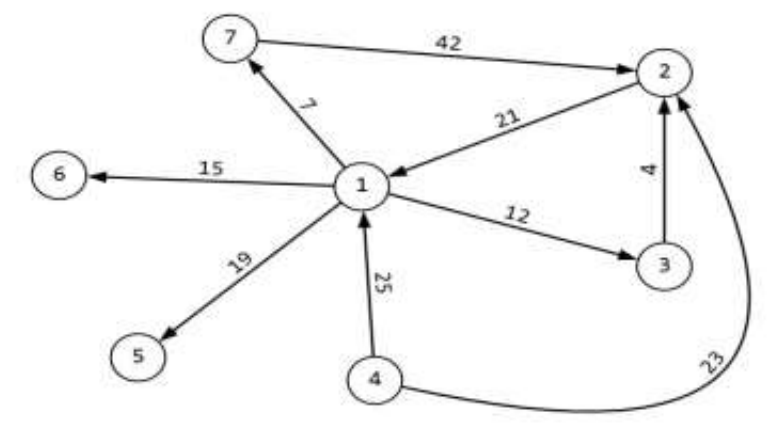
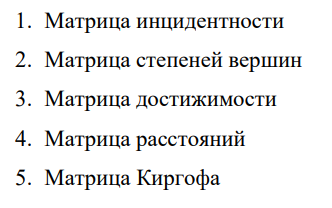

In [20]:
def print_matrix(mat, width=5):
    for row in mat:
        print("[", end="")
        for x in row:
            print(f"{x:>{width}}", end="")
        print(" ]")

In [41]:
matrix = [
    [0, 0, 12, 0, 19, 15, 7],
    [21, 0, 0, 0, 0, 0, 0],
    [0, 4, 0, 0, 0, 0, 0],
    [25, 23, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 42, 0, 0, 0, 0, 0]
]

print_matrix(matrix)

[    0    0   12    0   19   15    7 ]
[   21    0    0    0    0    0    0 ]
[    0    4    0    0    0    0    0 ]
[   25   23    0    0    0    0    0 ]
[    0    0    0    0    0    0    0 ]
[    0    0    0    0    0    0    0 ]
[    0   42    0    0    0    0    0 ]


In [7]:
count_v = len(matrix)
count_v

7

In [8]:
def count_e_func(matrix) -> int:
    count = 0
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            if matrix[i][j] != 0:
                count += 1
    return count
    

In [9]:
def get_e(matrix):
    e = []
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            if matrix[i][j] != 0:
                if ((i, j) not in e) and ((j, i) not in e):
                    e.append((i, j))
    return e


In [10]:
e = get_e(matrix)
e

[(0, 2), (0, 4), (0, 5), (0, 6), (1, 0), (2, 1), (3, 0), (3, 1), (6, 1)]

In [11]:
count_e = count_e_func(matrix)
count_e

9

#### 1. матрица инцидентности

In [16]:
def get_matrix_inqid(matrix):
    new_mat = [[0] * count_e for _ in range(count_v)]

    for k in range(count_e):
        i, j = e[k]
        w = matrix[i][j]

        new_mat[i][k] = -w   # откуда
        new_mat[j][k] = +w   # куда

    return new_mat

In [21]:
matrix_inqid = get_matrix_inqid(matrix)
print_matrix(matrix_inqid)

[  -12  -19  -15   -7   21    0   25    0    0 ]
[    0    0    0    0  -21    4    0   23   42 ]
[   12    0    0    0    0   -4    0    0    0 ]
[    0    0    0    0    0    0  -25  -23    0 ]
[    0   19    0    0    0    0    0    0    0 ]
[    0    0   15    0    0    0    0    0    0 ]
[    0    0    0    7    0    0    0    0  -42 ]


In [78]:
def print_incidence_with_headers(B, edges):
    # заголовок
    header = "     "
    for e in edges:
        header += f"{str(e):>8}"
    print(header)

    # строки
    for i, row in enumerate(B):
        line = f"v{i} | "
        for val in row:
            line += f"{val:>8}"
        print(line)

In [79]:
print_incidence_with_headers(matrix_inqid, e)

       (0, 2)  (0, 4)  (0, 5)  (0, 6)  (1, 0)  (2, 1)  (3, 0)  (3, 1)  (6, 1)
v0 |      -12     -19     -15      -7      21       0      25       0       0
v1 |        0       0       0       0     -21       4       0      23      42
v2 |       12       0       0       0       0      -4       0       0       0
v3 |        0       0       0       0       0       0     -25     -23       0
v4 |        0      19       0       0       0       0       0       0       0
v5 |        0       0      15       0       0       0       0       0       0
v6 |        0       0       0       7       0       0       0       0     -42


#### 2. Матрица степеней вершин

In [28]:
def get_matrix_ver(matrix):
    new_mat = [[0] * count_v for _ in range(count_v)]

    for i in range(count_v):
        out_deg = sum(matrix[i])                 # исходящие (сумма по строке)
        in_deg = sum(matrix[j][i] for j in range(count_v))  # входящие (сумма по столбцу)

        new_mat[i][i] = out_deg + in_deg

    return new_mat

In [48]:
# направления дуг не учитываются
matrix_ver = get_matrix_ver(matrix)
print_matrix(matrix_ver)

[   99    0    0    0    0    0    0 ]
[    0   90    0    0    0    0    0 ]
[    0    0   16    0    0    0    0 ]
[    0    0    0   48    0    0    0 ]
[    0    0    0    0   19    0    0 ]
[    0    0    0    0    0   15    0 ]
[    0    0    0    0    0    0   49 ]


#### 3. Матрица достижимости

In [34]:
def get_reachability_matrix(matrix):
    # 1. бинарная копия матрицы
    R = [[0]*count_v for _ in range(count_v)]
    for i in range(count_v):
        for j in range(count_v):
            if matrix[i][j] != 0:
                R[i][j] = 1
        R[i][i] = 1   # достижимость из себя

    # 2. алгоритм Уоршелла
    for k in range(count_v):
        for i in range(count_v):
            if R[i][k] == 1:
                for j in range(count_v):
                    if R[k][j] == 1:
                        R[i][j] = 1

    return R

In [39]:
reachability_matrix = get_reachability_matrix(matrix)
print_matrix(reachability_matrix)

[    1    1    1    0    1    1    1 ]
[    1    1    1    0    1    1    1 ]
[    1    1    1    0    1    1    1 ]
[    1    1    1    1    1    1    1 ]
[    0    0    0    0    1    0    0 ]
[    0    0    0    0    0    1    0 ]
[    1    1    1    0    1    1    1 ]


#### 4. Матрица расстояний

In [42]:
def get_matrix_distance(matrix, start):
    visited = [False] * count_v
    distance = [1000] * count_v
    distance[start] = 0
    for _ in range(count_v):
        v = -1
        min_d = 100
        for i in range(count_v): # перебираем непосещенные вершины и выбираем ту, до которой минимальное растояние
            if not visited[i] and distance[i] < min_d:
                min_d = distance[i]
                v = i # вершина, растояние до которой минимально

        if v == -1:
            break
        visited[v] = True
        
        for i in range(count_v): # берем строчку по вершине из пред. цикла из матрицы
            if matrix[v][i] != 0 and not visited[i]: # если в вершину есть дорога и мы ее еще не смотрели
                if distance[v] + matrix[v][i] < distance[i]: # то смотрим будет ли новый маршрут короче старого
                    distance[i] = distance[v] + matrix[v][i]

    return distance         


In [49]:
matrix_distance = []
for i in range(count_v):
    matrix_distance.append(get_matrix_distance(matrix, i))

print_matrix(matrix_distance)

[    0   16   12 1000   19   15    7 ]
[   21    0   33 1000   40   36   28 ]
[   25    4    0 1000   44   40   32 ]
[   25   23   37    0   44   40   32 ]
[ 1000 1000 1000 1000    0 1000 1000 ]
[ 1000 1000 1000 1000 1000    0 1000 ]
[   63   42   75 1000   82   78    0 ]


тысячи в выводе должны быть - это типо бесконечность и значит что пути нет

#### 5. Матрица Киргофа

In [69]:
def get_matrix_kirgof(matrix):
    # симметричная матрица смежности (без учета направлений)
    A = [[0]*count_v for _ in range(count_v)]
    for i in range(count_v):
        for j in range(count_v):
            if i != j:
                A[i][j] = matrix[i][j] + matrix[j][i]

    # матрица степени вершин
    matrix_ver = [[0]*count_v for _ in range(count_v)]
    for i in range(count_v):
        matrix_ver[i][i] = sum(A[i])
    
    for i in range(count_v):
        for j in range(count_v):
            if i != j:
                matrix_ver[i][j] = matrix_ver[i][j] - A[i][j]
    return matrix_ver

In [70]:
# направления дуг не учитываются
matrix_kirgof = get_matrix_kirgof(matrix)
print_matrix(matrix_kirgof)

[   99  -21  -12  -25  -19  -15   -7 ]
[  -21   90   -4  -23    0    0  -42 ]
[  -12   -4   16    0    0    0    0 ]
[  -25  -23    0   48    0    0    0 ]
[  -19    0    0    0   19    0    0 ]
[  -15    0    0    0    0   15    0 ]
[   -7  -42    0    0    0    0   49 ]


### Задание 2

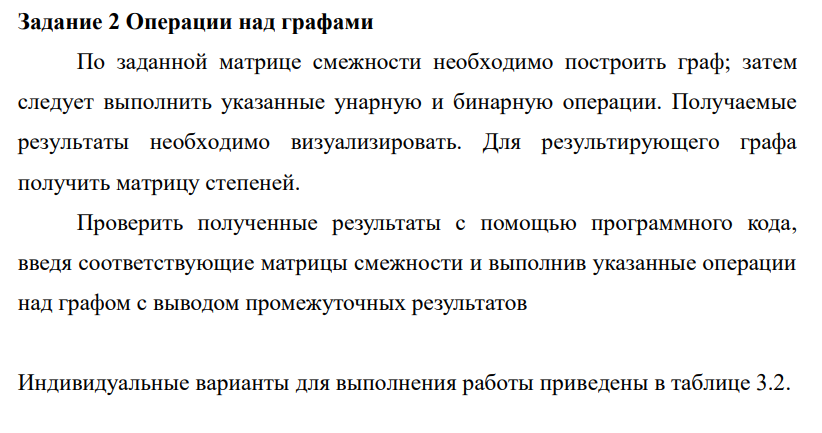

In [80]:
import numpy as np
M1 = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 1, 1],
    [0, 1, 1, 0, 0],
    [0, 1, 1, 0, 0]
])


# Граф G1 после унарной операции
M1_un = np.array([
    [0, 1, 1, 1, 1],
    [1, 0, 1, 0, 0],
    [1, 1, 0, 0, 0],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 1, 0]
])




# Граф G2
M2 = np.array([
    [0, 1, 1, 1],
    [1, 0, 1, 1],
    [1, 1, 0, 1],
    [1, 1, 1, 0]
])


def union_graphs_with_common_vertex(M1, M2):
    n1 = M1.shape[0]
    n2 = M2.shape[0]

    n = n1 + n2 - 1  # минус общая вершина
    R = np.zeros((n, n), dtype=int)

    # 1. Копируем G1 полностью
    R[:n1, :n1] = M1

    # 2. Копируем G2 (кроме первой вершины)
    R[0, n1:] = M2[0, 1:]      # связи общей вершины
    R[n1:, 0] = M2[1:, 0]

    R[n1:, n1:] = M2[1:, 1:]  # остальные вершины G2

    return R

M_union = union_graphs_with_common_vertex(M1_un, M2)
degrees = np.sum(M_union, axis=1)
D_matrix = np.diag(degrees)

print("\nМатрица смежности:")
print_matrix(M_union)

print("\nРазмер итоговой матрицы:", M_union.shape)
print("Степени вершин:", degrees)
print("\nМатрица степеней вершин:")
print_matrix(D_matrix)



Матрица смежности:
[    0    1    1    1    1    1    1    1 ]
[    1    0    1    0    0    0    0    0 ]
[    1    1    0    0    0    0    0    0 ]
[    1    0    0    0    1    0    0    0 ]
[    1    0    0    1    0    0    0    0 ]
[    1    0    0    0    0    0    1    1 ]
[    1    0    0    0    0    1    0    1 ]
[    1    0    0    0    0    1    1    0 ]

Размер итоговой матрицы: (8, 8)
Степени вершин: [7 2 2 2 2 3 3 3]

Матрица степеней вершин:
[    7    0    0    0    0    0    0    0 ]
[    0    2    0    0    0    0    0    0 ]
[    0    0    2    0    0    0    0    0 ]
[    0    0    0    2    0    0    0    0 ]
[    0    0    0    0    2    0    0    0 ]
[    0    0    0    0    0    3    0    0 ]
[    0    0    0    0    0    0    3    0 ]
[    0    0    0    0    0    0    0    3 ]
